In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Data

In [2]:
df = pd.read_csv('hospital_data_10000 (2).csv')
df

,Patient_ID,Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor,Department,Treatment_Cost
0,1,Allison Cruz,52,Female,Migraine,10/25/2025,11/1/2025,Dr. Verma,General Medicine,80020
1,2,Amber Murray,39,Female,Fracture,11/1/2024,11/3/2024,Dr. Rao,Orthopedics,132757
2,3,Tina Brewer,88,Female,Migraine,12/4/2023,12/9/2023,Dr. Singh,Cardiology,68436
3,4,Mrs. Felicia Evans,31,Male,Infection,2/20/2025,3/1/2025,Dr. Verma,Dermatology,145803
4,5,Christopher Green,38,Male,Fever,1/11/2025,1/22/2025,Dr. Reddy,Neurology,105231
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Mark Owens,55,Female,Diabetes,5/9/2025,5/13/2025,Dr. Verma,Oncology,84617
9996,9997,John Shannon,39,Male,Covid,4/17/2024,4/23/2024,Dr. Mehta,Oncology,80981
9997,9998,Hannah Klein,61,Female,Asthma,5/13/2025,5/23/2025,Dr. Singh,Cardiology,93715
9998,9999,Brian Mcdaniel,69,Male,Infection,8/31/2024,9/6/2024,Dr. Iyer,Dermatology,82972


In [3]:
df.shape

(10000, 10)

In [43]:
df.columns

Index(['Patient_ID', 'Name', 'Age', 'Gender', 'Disease', 'Admission_Date',
       'Discharge_Date', 'Doctor', 'Department', 'Treatment_Cost', 'Month',
       'Stay_Days'],
      dtype='object')

In [44]:
df.dtypes

Patient_ID                 int64
Name                      object
Age                        int64
Gender                    object
Disease                   object
Admission_Date    datetime64[ns]
Discharge_Date    datetime64[ns]
Doctor                    object
Department                object
Treatment_Cost             int64
Month                     object
Stay_Days                  int64
dtype: object

In [45]:
df.describe

<bound method NDFrame.describe of       Patient_ID                Name  Age  Gender    Disease Admission_Date  \
0              1        Allison Cruz   52  Female   Migraine     2025-10-25   
1              2        Amber Murray   39  Female   Fracture     2024-11-01   
2              3         Tina Brewer   88  Female   Migraine     2023-12-04   
3              4  Mrs. Felicia Evans   31    Male  Infection     2025-02-20   
4              5   Christopher Green   38    Male      Fever     2025-01-11   
...          ...                 ...  ...     ...        ...            ...   
9995        9996          Mark Owens   55  Female   Diabetes     2025-05-09   
9996        9997        John Shannon   39    Male      Covid     2024-04-17   
9997        9998        Hannah Klein   61  Female     Asthma     2025-05-13   
9998        9999      Brian Mcdaniel   69    Male  Infection     2024-08-31   
9999       10000     Michael Krueger   51    Male     Asthma     2024-06-07   

     Discharge_Da

### Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Name            10000 non-null  object
 2   Age             10000 non-null  int64 
 3   Gender          10000 non-null  object
 4   Disease         10000 non-null  object
 5   Admission_Date  10000 non-null  object
 6   Discharge_Date  10000 non-null  object
 7   Doctor          10000 non-null  object
 8   Department      10000 non-null  object
 9   Treatment_Cost  10000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 781.4+ KB


Patient_ID        0
Name              0
Age               0
Gender            0
Disease           0
Admission_Date    0
Discharge_Date    0
Doctor            0
Department        0
Treatment_Cost    0
dtype: int64

In [ ]:
df.isnull().sum()

### Data cleaning

#### 1. convert the dates

In [50]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])
df

,Patient_ID,Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor,Department,Treatment_Cost
0,1,Allison Cruz,52,Female,Migraine,2025-10-25,2025-11-01,Dr. Verma,General Medicine,80020
1,2,Amber Murray,39,Female,Fracture,2024-11-01,2024-11-03,Dr. Rao,Orthopedics,132757
2,3,Tina Brewer,88,Female,Migraine,2023-12-04,2023-12-09,Dr. Singh,Cardiology,68436
3,4,Mrs. Felicia Evans,31,Male,Infection,2025-02-20,2025-03-01,Dr. Verma,Dermatology,145803
4,5,Christopher Green,38,Male,Fever,2025-01-11,2025-01-22,Dr. Reddy,Neurology,105231
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Mark Owens,55,Female,Diabetes,2025-05-09,2025-05-13,Dr. Verma,Oncology,84617
9996,9997,John Shannon,39,Male,Covid,2024-04-17,2024-04-23,Dr. Mehta,Oncology,80981
9997,9998,Hannah Klein,61,Female,Asthma,2025-05-13,2025-05-23,Dr. Singh,Cardiology,93715
9998,9999,Brian Mcdaniel,69,Male,Infection,2024-08-31,2024-09-06,Dr. Iyer,Dermatology,82972


### Find missing values

In [46]:
df.isnull().sum() 

Patient_ID        0
Name              0
Age               0
Gender            0
Disease           0
Admission_Date    0
Discharge_Date    0
Doctor            0
Department        0
Treatment_Cost    0
Month             0
Stay_Days         0
dtype: int64

### handle Missing values

In [54]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Gender'] = df['Gender'].fillna("unknown")
df['Age']
df['Gender'] 

0       Female
1       Female
2       Female
3         Male
4         Male
         ...  
9995    Female
9996      Male
9997    Female
9998      Male
9999      Male
Name: Gender, Length: 10000, dtype: object

#### Remove duplicate rows

In [56]:
df.drop_duplicates(inplace=True) 

### find no.of patients in each department

In [58]:
df['Department'].value_counts() 

Department
Cardiology          1483
Oncology            1452
Orthopedics         1440
Dermatology         1436
Neurology           1412
General Medicine    1390
Pediatrics          1387
Name: count, dtype: int64

#### Filtering Data

#### Patients who stayed more than 5 days

In [60]:
long_Stay = df[df['Stay_Days']>5]
print(long_Stay.head()) 

   Patient_ID                Name  Age  Gender    Disease Admission_Date  \
0           1        Allison Cruz   52  Female   Migraine     2025-10-25   
3           4  Mrs. Felicia Evans   31    Male  Infection     2025-02-20   
4           5   Christopher Green   38    Male      Fever     2025-01-11   
5           6       Maria Nichols   89  Female     Asthma     2024-11-11   
6           7    Lindsey Thompson   68    Male     Asthma     2024-04-27   

  Discharge_Date     Doctor        Department  Treatment_Cost     Month  \
0     2025-11-01  Dr. Verma  General Medicine           80020   October   
3     2025-03-01  Dr. Verma       Dermatology          145803  February   
4     2025-01-22  Dr. Reddy         Neurology          105231   January   
5     2024-11-19   Dr. Iyer       Dermatology           99393  November   
6     2024-05-07   Dr. Iyer       Dermatology           81017     April   

   Stay_Days  
0          7  
3          9  
4         11  
5          8  
6         10  


#### 2. Calculate hospital stay duration

In [26]:
df['Stay_Days'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days
df['Stay_Days'] 

0        7
1        2
2        5
3        9
4       11
        ..
9995     4
9996     6
9997    10
9998     6
9999     9
Name: Stay_Days, Length: 10000, dtype: int64

#### 3. Remove invalid stays

In [27]:
df=df[df['Stay_Days']>=0]
df 

,Patient_ID,Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor,Department,Treatment_Cost,Month,Stay_Days
0,1,Allison Cruz,52,Female,Migraine,2025-10-25,2025-11-01,Dr. Verma,General Medicine,80020,October,7
1,2,Amber Murray,39,Female,Fracture,2024-11-01,2024-11-03,Dr. Rao,Orthopedics,132757,November,2
2,3,Tina Brewer,88,Female,Migraine,2023-12-04,2023-12-09,Dr. Singh,Cardiology,68436,December,5
3,4,Mrs. Felicia Evans,31,Male,Infection,2025-02-20,2025-03-01,Dr. Verma,Dermatology,145803,February,9
4,5,Christopher Green,38,Male,Fever,2025-01-11,2025-01-22,Dr. Reddy,Neurology,105231,January,11
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Mark Owens,55,Female,Diabetes,2025-05-09,2025-05-13,Dr. Verma,Oncology,84617,May,4
9996,9997,John Shannon,39,Male,Covid,2024-04-17,2024-04-23,Dr. Mehta,Oncology,80981,April,6
9997,9998,Hannah Klein,61,Female,Asthma,2025-05-13,2025-05-23,Dr. Singh,Cardiology,93715,May,10
9998,9999,Brian Mcdaniel,69,Male,Infection,2024-08-31,2024-09-06,Dr. Iyer,Dermatology,82972,August,6


#### 4. clean the text columns 

In [58]:
df['Disease'] = df['Disease'].str.title()
df['Disease']                                

0        Migraine
1        Fracture
2        Migraine
3       Infection
4           Fever
          ...    
9995     Diabetes
9996        Covid
9997       Asthma
9998    Infection
9999       Asthma
Name: Disease, Length: 10000, dtype: object

In [59]:
df['Deparment'] = df['Department'].str.title()
df['Department']                                

0       General Medicine
1            Orthopedics
2             Cardiology
3            Dermatology
4              Neurology
              ...       
9995            Oncology
9996            Oncology
9997          Cardiology
9998         Dermatology
9999         Orthopedics
Name: Department, Length: 10000, dtype: object

In [60]:
df['Doctor'] = df['Doctor'].str.title()
df['Doctor']                                

0       Dr. Verma
1         Dr. Rao
2       Dr. Singh
3       Dr. Verma
4       Dr. Reddy
          ...    
9995    Dr. Verma
9996    Dr. Mehta
9997    Dr. Singh
9998     Dr. Iyer
9999    Dr. Reddy
Name: Doctor, Length: 10000, dtype: object

##### Most Common Disease

In [7]:
common_disease = df['Disease'].value_counts().idxmax()
print("Most Common Disease:",common_disease)

Most Common Disease: Infection


##### Doctor with Highest Number of Patients

In [10]:
top_doctor = df['Doctor'].value_counts().idxmax()
print("Doctor with Most patients:",top_doctor)

Doctor with Most patients: Dr. Sharma


##### Avg treatment cost

In [14]:
avg_cost = df['Treatment_Cost'].mean()
print(avg_cost)

78028.2535


##### Gender Distribution of Patients

In [15]:
gender_dist = df['Gender'].value_counts()
print("Gender Distribution:\n", gender_dist)

Gender Distribution:
 Gender
Male      5031
Female    4969
Name: count, dtype: int64


#### Age Group Distribution

In [16]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,18,40,60,100],
                         labels=['Child','Young Adult','Middle Age','Senior'])

print(df['Age_Group'].value_counts())

Age_Group
Senior         3279
Young Adult    2492
Middle Age     2189
Child          2040
Name: count, dtype: int64


##### Calculate Length of Stays

In [18]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

# Calculate length of stay
df['Stay_Length'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days

print(df['Stay_Length'].describe())

count    10000.0000
mean         8.0180
std          4.3174
min          1.0000
25%          4.0000
50%          8.0000
75%         12.0000
max         15.0000
Name: Stay_Length, dtype: float64


##### Month-wise Adimissions

In [19]:
df['Month'] = df['Admission_Date'].dt.month_name()
print(df['Month'].value_counts())

Month
October      875
April        866
June         856
December     855
November     847
May          843
July         843
January      836
September    829
August       822
March        805
February     723
Name: count, dtype: int64


##### Highest treatment cost

In [22]:
highest_cost = df.loc[df['Treatment_Cost'].idxmax()]
print("Patient with highest treatment cost:\n", highest_cost)

Patient with highest treatment cost:
 Patient_ID                       6253
Name                   Jeremy Coleman
Age                                36
Gender                           Male
Disease                        Cancer
Admission_Date    2024-04-30 00:00:00
Discharge_Date    2024-05-06 00:00:00
Doctor                      Dr. Verma
Department           General Medicine
Treatment_Cost                 149984
Age_Group                 Young Adult
Stay_Length                         6
Month                           April
Name: 6252, dtype: object


###### Total Revenue Generated

In [24]:
total_revenue = df['Treatment_Cost'].sum()
print("Total Revenue Generated:", total_revenue)

Total Revenue Generated: 780282535


##### Disease-wise Avg Stay length

In [25]:
disease_stay = df.groupby('Disease')['Stay_Length'].mean()
print(disease_stay)

Disease
Allergy         8.381188
Asthma          7.981972
Cancer          8.259790
Covid           7.871897
Diabetes        7.845610
Fever           8.072134
Fracture        7.868987
Hypertension    7.919003
Infection       7.982857
Migraine        7.973000
Name: Stay_Length, dtype: float64


#### EDA (Exploratory Data Analysis)

#### 1. Age Distribution

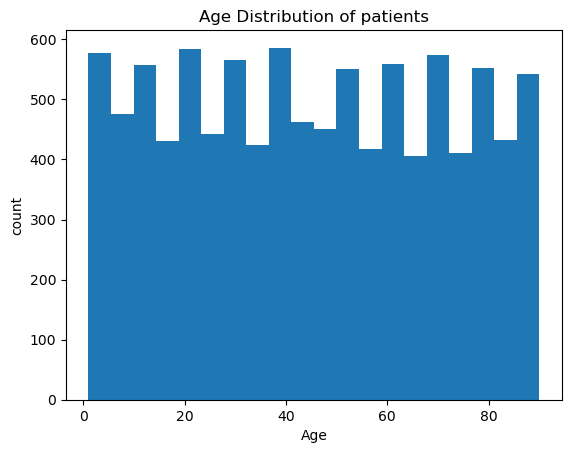

In [63]:
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution of patients")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()                                      

#### 2. Gender Distribution

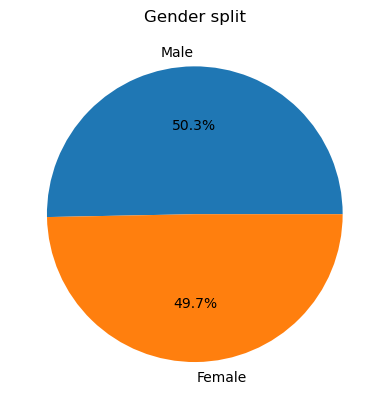

In [65]:
df['Gender'].value_counts().plot(kind = 'pie',autopct='%1.1f%%')
plt.title("Gender split")
plt.ylabel("")
plt.show()                                                          

#### 3. Most common Diseases

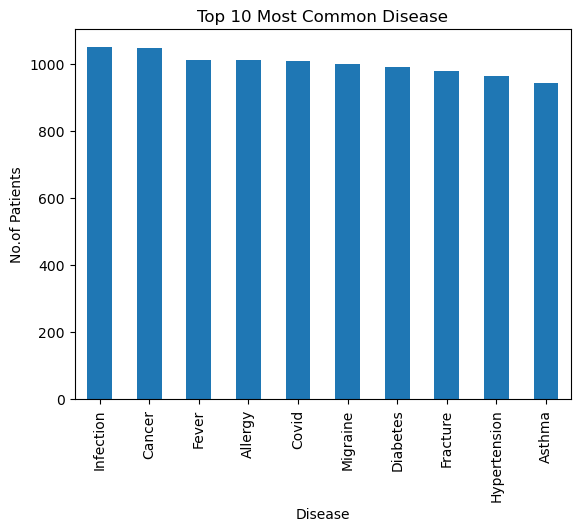

In [66]:
df['Disease'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Disease")
plt.xlabel("Disease")
plt.ylabel("No.of Patients")                                                  
plt.show()

#### 4. Patients per Department

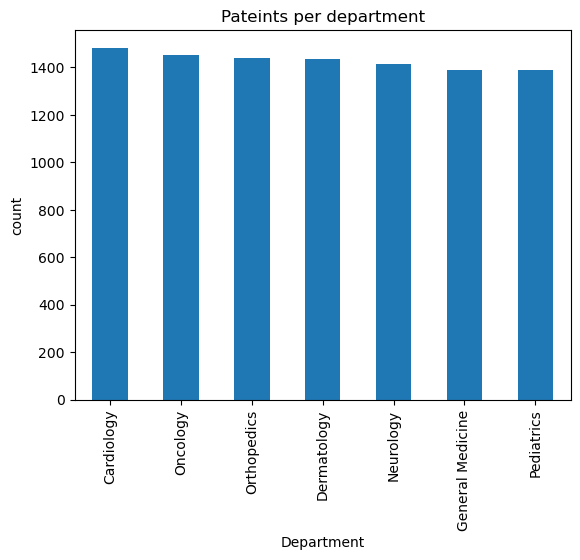

In [8]:
df['Department'].value_counts().plot(kind='bar')
plt.title("Pateints per department")
plt.xlabel("Department")
plt.ylabel("count")
plt.show()                                                  

#### 5. Monthly Admissions

In [18]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce')
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'], errors='coerce')

# Now extract month name
df['Month'] = df['Admission_Date'].dt.month_name()

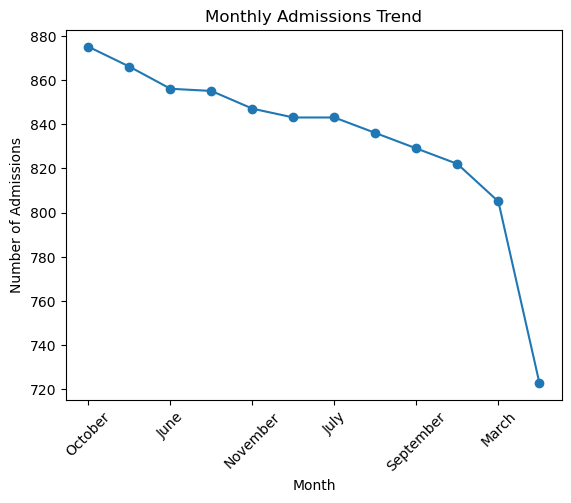

In [19]:
df['Month'] = df['Admission_Date'].dt.month_name()

df['Month'].value_counts().plot(kind='line', marker='o')
plt.title("Monthly Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.show()

##### 6.Avg Stay days

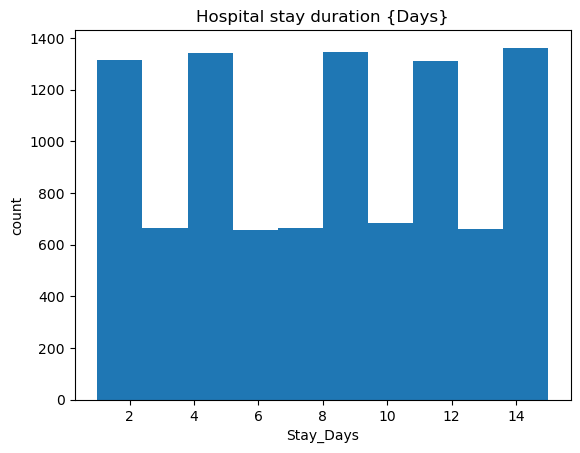

np.float64(8.018)

In [29]:
df['Stay_Days'].plot(kind='hist')
plt.title("Hospital stay duration {Days}")
plt.xlabel("Stay_Days")
plt.ylabel("count")
plt.show()
df['Stay_Days'].mean()                              

#### 7. Patients per Doctor

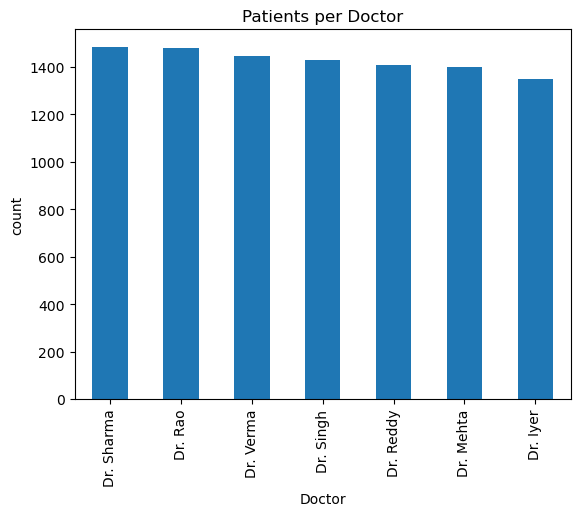

In [24]:
df['Doctor'].value_counts().plot(kind='bar')
plt.title("Patients per Doctor")
plt.xlabel("Doctor")
plt.ylabel("count")
plt.show()                                               

#### 8. Treatment Cost Distribution

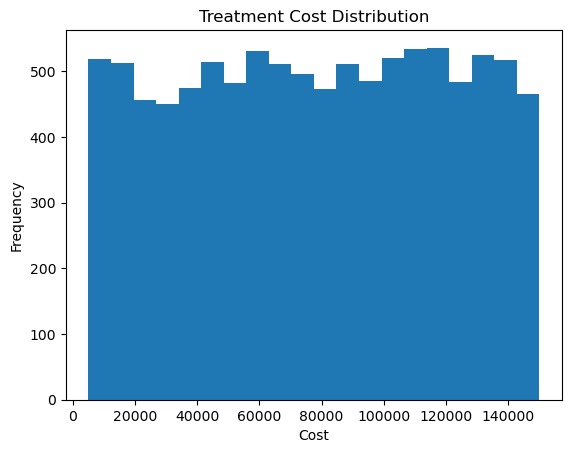

In [25]:
plt.hist(df['Treatment_Cost'], bins=20)
plt.title("Treatment Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()                                                

#### Show the specific row

In [32]:
df['Stay_Days'].describe()

count    10000.0000
mean         8.0180
std          4.3174
min          1.0000
25%          4.0000
50%          8.0000
75%         12.0000
max         15.0000
Name: Stay_Days, dtype: float64

In [33]:
df['Stay_Days'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Stay_Days
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [31]:
df.loc[10,'Stay_Days']

np.int64(14)

#### check the dtype

In [34]:
df[['Admission_Date','Discharge_Date']].dtypes

Admission_Date    datetime64[ns]
Discharge_Date    datetime64[ns]
dtype: object

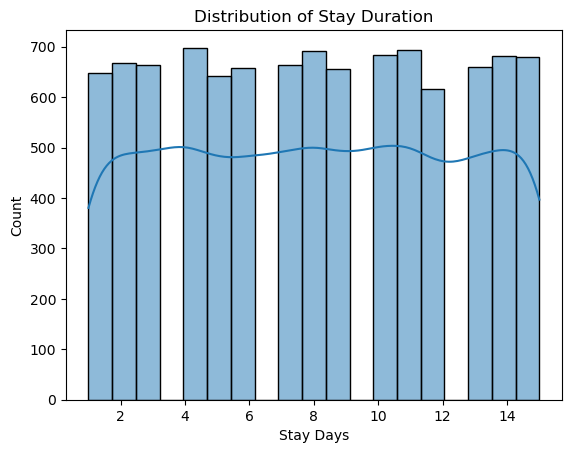

In [36]:
sns.histplot(df['Stay_Days'], kde=True)
plt.title("Distribution of Stay Duration")
plt.xlabel("Stay Days")
plt.ylabel("Count")
plt.show()                                                 

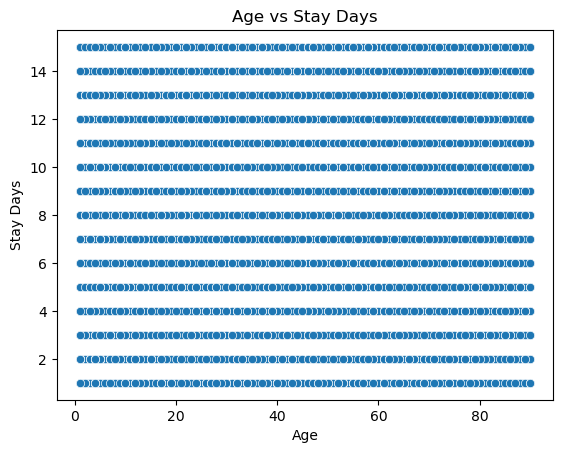

In [37]:
sns.scatterplot(x='Age', y='Stay_Days', data=df)
plt.title("Age vs Stay Days")
plt.xlabel("Age")
plt.ylabel("Stay Days")
plt.show()                                                           

#### No.of Patients by Department

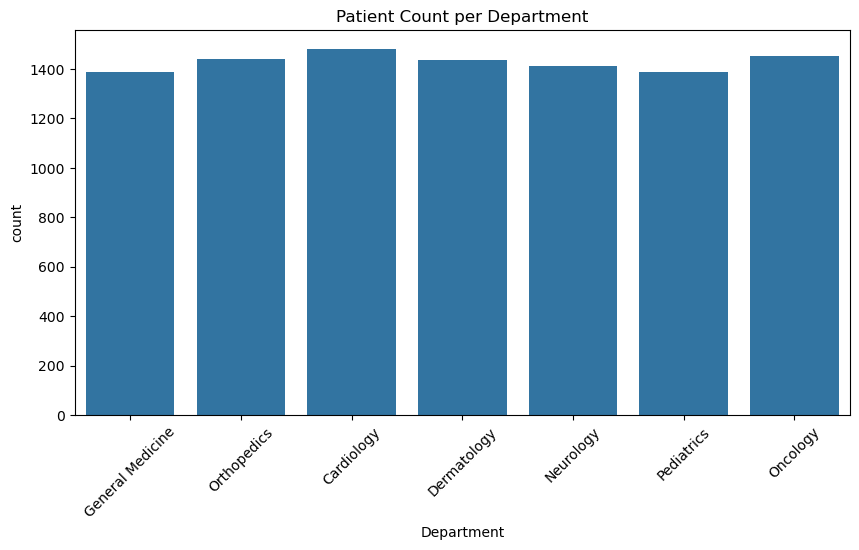

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(x='Department', data=df)
plt.title("Patient Count per Department")
plt.xticks(rotation=45)
plt.show()                                       

#### Gender Distribution

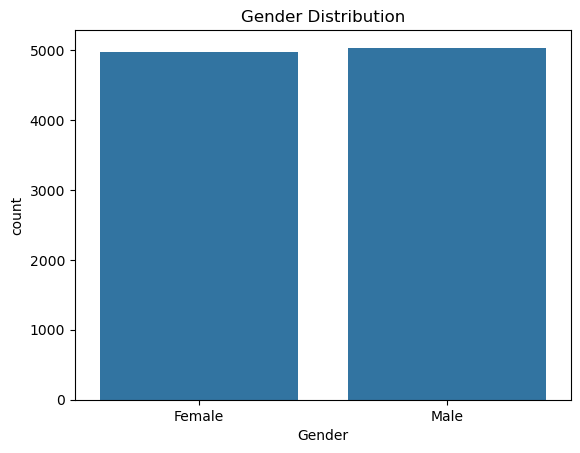

In [39]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

#### pivot Tables

#### Avg Stay by Department and Age Group

In [62]:
pivot1 = df.pivot_table(values='Stay_Days', index='Department', columns='Age', aggfunc='mean')
print(pivot1)                                                                                     

Age                      1         2          3         4          5   \
Department                                                              
Cardiology         7.230769  6.764706   8.700000  6.812500   8.500000   
Dermatology        7.312500  8.153846   7.421053  7.647059  10.454545   
General Medicine   8.357143  7.750000   8.217391  7.666667   8.538462   
Neurology         10.400000  7.705882   8.642857  6.900000   9.222222   
Oncology           8.733333  8.647059   9.636364  8.333333   8.769231   
Orthopedics        8.950000  8.782609  10.157895  8.642857   5.944444   
Pediatrics         7.346154  8.647059   7.117647  6.789474   6.578947   

Age                      6         7         8         9         10  ...  \
Department                                                           ...   
Cardiology         7.083333  9.076923  8.176471  5.500000  8.416667  ...   
Dermatology        8.666667  9.300000  7.090909  7.157895  8.400000  ...   
General Medicine   8.619048  6.142857 

#### Doctor-wise month;ly patient load

In [64]:
pivot2 = df.pivot_table(values='Patient_ID', index='Doctor', columns='Admission_Date', aggfunc='count')
print(pivot2)                                                                                                

Admission_Date  2023-11-04  2023-11-05  2023-11-06  2023-11-07  2023-11-08  \
Doctor                                                                       
Dr. Iyer               1.0         5.0         1.0         1.0         2.0   
Dr. Mehta              1.0         5.0         3.0         1.0         NaN   
Dr. Rao                1.0         3.0         6.0         5.0         2.0   
Dr. Reddy              3.0         3.0         1.0         3.0         2.0   
Dr. Sharma             1.0         NaN         1.0         3.0         1.0   
Dr. Singh              2.0         2.0         3.0         NaN         2.0   
Dr. Verma              2.0         2.0         1.0         3.0         1.0   

Admission_Date  2023-11-09  2023-11-10  2023-11-11  2023-11-12  2023-11-13  \
Doctor                                                                       
Dr. Iyer               NaN         4.0         1.0         1.0         NaN   
Dr. Mehta              NaN         1.0         2.0         3.0 

#### Group by Insights

#### Age distribution by Department

In [66]:
print(df.groupby('Department')['Age'].value_counts())

Department  Age
Cardiology  38     26
            16     25
            6      24
            10     24
            13     24
                   ..
Pediatrics  12      8
            34      8
            66      8
            75      7
            43      6
Name: count, Length: 630, dtype: int64
